In [19]:
# ===============================
# 1. IMPORTS & LOAD RESULTS
# ===============================
import os
import sys
import numpy as np
import pandas as pd

from scipy import stats
from scipy.stats import shapiro, wilcoxon, ttest_rel

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.metrics import confusion_matrix
from transformers import BertForSequenceClassification, BertTokenizer

SEEDS = [42, 123, 456, 789, 1011, 1213, 1415, 1617, 1819, 2021]
BASE_DIR   = os.path.dirname(os.getcwd())
RAW_DIR  = os.path.join(BASE_DIR, "data", "raw")
PROC_DIR = os.path.join(BASE_DIR, "data", "processed")
MODELS_DIR = os.path.join(BASE_DIR, "models")
PLOTS_DIR = os.path.join(BASE_DIR, "plots")

os.makedirs(PLOTS_DIR, exist_ok=True)

# Consistent style across all plots
plt.rcParams.update({
    "figure.dpi":    150,
    "font.size":     12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
})

rq1_df = pd.read_csv(os.path.join(MODELS_DIR, "rq1_bert_results.csv"))
rq2_df = pd.read_csv(os.path.join(MODELS_DIR, "rq2_bert_results.csv"))
rq3_df = pd.read_csv(os.path.join(MODELS_DIR, "rq3_bert_results.csv"))

print("RQ1 shape:", rq1_df.shape)  # expected: 30 (3 datasets × 10 seeds)
print("RQ2 shape:", rq2_df.shape)  # expected: 20 (2 conditions × 10 seeds)
print("RQ3 shape:", rq3_df.shape)  # expected: 60 (6 pairs × 10 seeds)

RQ1 shape: (30, 8)
RQ2 shape: (20, 8)
RQ3 shape: (60, 10)


In [2]:
# ===============================
# 2. NORMALITY TESTING UTILITY
# ===============================
def check_normality(scores, label):
    """
    Shapiro-Wilk test for normality.
    n=10 so Shapiro-Wilk is the correct choice (sensitive to small samples).
    p > 0.05 → normal → t-test
    p <= 0.05 → not normal → Wilcoxon
    """
    stat, p = shapiro(scores)
    normal  = p > 0.05
    print(f"  {label}")
    print(f"    n={len(scores)}  mean={np.mean(scores):.4f}  "
          f"std={np.std(scores):.4f}")
    print(f"    Shapiro-Wilk: W={stat:.4f}  p={p:.4f}  "
          f"→ {'NORMAL' if normal else 'NOT NORMAL'}")
    return normal, p

In [4]:
# ===============================
# 3. NORMALITY — RQ1
# ===============================
print("=" * 60)
print("NORMALITY TESTS — RQ1 (F1 Macro per dataset)")
print("=" * 60)

rq1_normality = {}

for dataset in ["Headlines", "Reddit", "SemEval"]:
    print(f"\n{dataset}:")
    scores = rq1_df[rq1_df["dataset"] == dataset]["f1_macro"].values
    normal, p = check_normality(scores, f"BERT (no context)")
    rq1_normality[dataset] = normal

NORMALITY TESTS — RQ1 (F1 Macro per dataset)

Headlines:
  BERT (no context)
    n=10  mean=0.9300  std=0.0013
    Shapiro-Wilk: W=0.9561  p=0.7405  → NORMAL

Reddit:
  BERT (no context)
    n=10  mean=0.7225  std=0.0032
    Shapiro-Wilk: W=0.9477  p=0.6419  → NORMAL

SemEval:
  BERT (no context)
    n=10  mean=0.9529  std=0.0037
    Shapiro-Wilk: W=0.8339  p=0.0373  → NOT NORMAL


In [5]:
# ===============================
# 4. NORMALITY — RQ2
# ===============================
print("=" * 60)
print("NORMALITY TESTS — RQ2 (F1 Macro per condition)")
print("=" * 60)

rq2_normality = {}

for model in ["BERT (no context)", "BERT (dual encoder)"]:
    print(f"\n{model}:")
    scores = rq2_df[rq2_df["model"] == model]["f1_macro"].values
    normal, p = check_normality(scores, model)
    rq2_normality[model] = normal

# Both conditions must be normal for t-test
rq2_both_normal = all(rq2_normality.values())
print(f"\nBoth RQ2 conditions normal: {rq2_both_normal}")
print(f"→ Use {'paired t-test' if rq2_both_normal else 'Wilcoxon signed-rank test'}")

NORMALITY TESTS — RQ2 (F1 Macro per condition)

BERT (no context):
  BERT (no context)
    n=10  mean=0.7225  std=0.0032
    Shapiro-Wilk: W=0.9477  p=0.6419  → NORMAL

BERT (dual encoder):
  BERT (dual encoder)
    n=10  mean=0.7211  std=0.0056
    Shapiro-Wilk: W=0.9259  p=0.4084  → NORMAL

Both RQ2 conditions normal: True
→ Use paired t-test


In [6]:
# ===============================
# 5. NORMALITY — RQ3
# ===============================
print("=" * 60)
print("NORMALITY TESTS — RQ3 (F1 Macro per domain pair)")
print("=" * 60)

rq3_normality = {}

for pair in rq3_df["dataset"].unique():
    print(f"\n{pair}:")
    scores = rq3_df[rq3_df["dataset"] == pair]["f1_macro"].values
    normal, p = check_normality(scores, pair)
    rq3_normality[pair] = normal

# Also check by train domain (for cross-domain comparison)
print("\n--- By Train Domain ---")
rq3_train_normality = {}
for train_domain in rq3_df["train_domain"].unique():
    print(f"\nTrain domain: {train_domain}")
    scores = rq3_df[rq3_df["train_domain"] == train_domain]["f1_macro"].values
    normal, p = check_normality(scores, train_domain)
    rq3_train_normality[train_domain] = normal

NORMALITY TESTS — RQ3 (F1 Macro per domain pair)

Headlines → Reddit:
  Headlines → Reddit
    n=10  mean=0.4035  std=0.0096
    Shapiro-Wilk: W=0.8437  p=0.0489  → NOT NORMAL

Headlines → SemEval:
  Headlines → SemEval
    n=10  mean=0.4371  std=0.0158
    Shapiro-Wilk: W=0.9028  p=0.2353  → NORMAL

Reddit → Headlines:
  Reddit → Headlines
    n=10  mean=0.4764  std=0.0173
    Shapiro-Wilk: W=0.9274  p=0.4225  → NORMAL

Reddit → SemEval:
  Reddit → SemEval
    n=10  mean=0.5860  std=0.0159
    Shapiro-Wilk: W=0.8900  p=0.1694  → NORMAL

SemEval → Headlines:
  SemEval → Headlines
    n=10  mean=0.3444  std=0.0003
    Shapiro-Wilk: W=0.8478  p=0.0547  → NORMAL

SemEval → Reddit:
  SemEval → Reddit
    n=10  mean=0.3334  std=0.0038
    Shapiro-Wilk: W=0.9298  p=0.4460  → NORMAL

--- By Train Domain ---

Train domain: Headlines
  Headlines
    n=20  mean=0.4203  std=0.0213
    Shapiro-Wilk: W=0.9304  p=0.1570  → NORMAL

Train domain: Reddit
  Reddit
    n=20  mean=0.5312  std=0.0572
    S

In [7]:
# ===============================
# 6. STATISTICAL TESTING UTILITY
# ===============================
def run_test(scores_a, scores_b, label_a, label_b, use_ttest=False):
    """
    Run paired t-test or Wilcoxon signed-rank test.
    Returns stat, p-value, and whether result is significant.
    """
    assert len(scores_a) == len(scores_b), "Paired test requires equal length"

    if use_ttest:
        stat, p = ttest_rel(scores_a, scores_b)
        test_name = "Paired t-test"
    else:
        # Wilcoxon requires non-zero differences
        if np.all(scores_a == scores_b):
            print(f"  WARNING: All differences are zero — cannot run Wilcoxon")
            return None, None, False
        stat, p = wilcoxon(scores_a, scores_b)
        test_name = "Wilcoxon signed-rank"

    significant = p < 0.05
    direction   = ">" if np.mean(scores_a) > np.mean(scores_b) else "<"

    print(f"\n  {test_name}: {label_a} vs {label_b}")
    print(f"    mean {label_a}: {np.mean(scores_a):.4f}")
    print(f"    mean {label_b}: {np.mean(scores_b):.4f}")
    print(f"    {label_a} {direction} {label_b}")
    print(f"    stat={stat:.4f}  p={p:.4f}")
    print(f"    → {'SIGNIFICANT (p<0.05)' if significant else 'NOT SIGNIFICANT (p>=0.05)'}")

    return stat, p, significant

In [8]:
# ===============================
# 7. STATISTICAL TESTS — RQ1
# ===============================
print("=" * 60)
print("STATISTICAL TESTS — RQ1")
print("Comparing datasets: is performance difference significant?")
print("=" * 60)

hl_scores = rq1_df[rq1_df["dataset"] == "Headlines"]["f1_macro"].values
rd_scores = rq1_df[rq1_df["dataset"] == "Reddit"]["f1_macro"].values
se_scores = rq1_df[rq1_df["dataset"] == "SemEval"]["f1_macro"].values

# Use t-test if both datasets being compared are normal
# otherwise Wilcoxon
print("\n--- Headlines vs Reddit ---")
use_t = rq1_normality["Headlines"] and rq1_normality["Reddit"]
run_test(hl_scores, rd_scores, "Headlines", "Reddit", use_ttest=use_t)

print("\n--- Headlines vs SemEval ---")
use_t = rq1_normality["Headlines"] and rq1_normality["SemEval"]
run_test(hl_scores, se_scores, "Headlines", "SemEval", use_ttest=use_t)

print("\n--- Reddit vs SemEval ---")
use_t = rq1_normality["Reddit"] and rq1_normality["SemEval"]
run_test(rd_scores, se_scores, "Reddit", "SemEval", use_ttest=use_t)

STATISTICAL TESTS — RQ1
Comparing datasets: is performance difference significant?

--- Headlines vs Reddit ---

  Paired t-test: Headlines vs Reddit
    mean Headlines: 0.9300
    mean Reddit: 0.7225
    Headlines > Reddit
    stat=199.4744  p=0.0000
    → SIGNIFICANT (p<0.05)

--- Headlines vs SemEval ---

  Wilcoxon signed-rank: Headlines vs SemEval
    mean Headlines: 0.9300
    mean SemEval: 0.9529
    Headlines < SemEval
    stat=0.0000  p=0.0020
    → SIGNIFICANT (p<0.05)

--- Reddit vs SemEval ---

  Wilcoxon signed-rank: Reddit vs SemEval
    mean Reddit: 0.7225
    mean SemEval: 0.9529
    Reddit < SemEval
    stat=0.0000  p=0.0020
    → SIGNIFICANT (p<0.05)


(np.float64(0.0), np.float64(0.001953125), np.True_)

In [9]:
# ===============================
# 8. STATISTICAL TESTS — RQ2
# ===============================
print("=" * 60)
print("STATISTICAL TESTS — RQ2")
print("Does dual encoder significantly outperform no context?")
print("=" * 60)

# Align by seed for paired test
rq2_pivot = rq2_df.pivot(index="seed", columns="model", values="f1_macro")
print("\nPaired scores per seed:")
print(rq2_pivot.to_string())

no_ctx_scores   = rq2_pivot["BERT (no context)"].values
dual_enc_scores = rq2_pivot["BERT (dual encoder)"].values

run_test(
    dual_enc_scores,
    no_ctx_scores,
    "BERT (dual encoder)",
    "BERT (no context)",
    use_ttest=rq2_both_normal
)

STATISTICAL TESTS — RQ2
Does dual encoder significantly outperform no context?

Paired scores per seed:
model  BERT (dual encoder)  BERT (no context)
seed                                         
42                0.713029           0.723781
123               0.729524           0.727895
456               0.727411           0.721910
789               0.723731           0.723189
1011              0.720192           0.722891
1213              0.715339           0.721375
1415              0.720599           0.725794
1617              0.713576           0.716798
1819              0.727354           0.717491
2021              0.720495           0.724167

  Paired t-test: BERT (dual encoder) vs BERT (no context)
    mean BERT (dual encoder): 0.7211
    mean BERT (no context): 0.7225
    BERT (dual encoder) < BERT (no context)
    stat=-0.7437  p=0.4760
    → NOT SIGNIFICANT (p>=0.05)


(np.float64(-0.7436583312582998), np.float64(0.47604809929666714), np.False_)

In [10]:
# ===============================
# 9. STATISTICAL TESTS — RQ3
# ===============================
print("=" * 60)
print("STATISTICAL TESTS — RQ3")
print("Is cross-domain drop significant vs in-domain?")
print("=" * 60)

# Compare each train domain's cross-domain F1 vs its in-domain F1
for train_domain in ["Headlines", "Reddit", "SemEval"]:
    print(f"\n--- {train_domain}: in-domain vs cross-domain ---")

    # In-domain scores from RQ1
    indomain_scores = rq1_df[
        rq1_df["dataset"] == train_domain
    ]["f1_macro"].values

    # Cross-domain scores — all pairs where this domain was the trainer
    crossdomain_scores = rq3_df[
        rq3_df["train_domain"] == train_domain
    ].groupby("seed")["f1_macro"].mean().values

    use_t = rq1_normality[train_domain] and rq3_train_normality[train_domain]
    run_test(
        indomain_scores,
        crossdomain_scores,
        f"{train_domain} in-domain",
        f"{train_domain} cross-domain",
        use_ttest=use_t
    )

# Compare train domains against each other cross-domain
print("\n--- Cross-domain: Reddit vs Headlines as train domain ---")
rd_cross  = rq3_df[rq3_df["train_domain"] == "Reddit"].groupby("seed")["f1_macro"].mean().values
hl_cross  = rq3_df[rq3_df["train_domain"] == "Headlines"].groupby("seed")["f1_macro"].mean().values
se_cross  = rq3_df[rq3_df["train_domain"] == "SemEval"].groupby("seed")["f1_macro"].mean().values

use_t = rq3_train_normality["Reddit"] and rq3_train_normality["Headlines"]
run_test(rd_cross, hl_cross, "Reddit (train)", "Headlines (train)", use_ttest=use_t)

print("\n--- Cross-domain: Reddit vs SemEval as train domain ---")
use_t = rq3_train_normality["Reddit"] and rq3_train_normality["SemEval"]
run_test(rd_cross, se_cross, "Reddit (train)", "SemEval (train)", use_ttest=use_t)

STATISTICAL TESTS — RQ3
Is cross-domain drop significant vs in-domain?

--- Headlines: in-domain vs cross-domain ---

  Paired t-test: Headlines in-domain vs Headlines cross-domain
    mean Headlines in-domain: 0.9300
    mean Headlines cross-domain: 0.4203
    Headlines in-domain > Headlines cross-domain
    stat=142.0987  p=0.0000
    → SIGNIFICANT (p<0.05)

--- Reddit: in-domain vs cross-domain ---

  Wilcoxon signed-rank: Reddit in-domain vs Reddit cross-domain
    mean Reddit in-domain: 0.7225
    mean Reddit cross-domain: 0.5312
    Reddit in-domain > Reddit cross-domain
    stat=0.0000  p=0.0020
    → SIGNIFICANT (p<0.05)

--- SemEval: in-domain vs cross-domain ---

  Wilcoxon signed-rank: SemEval in-domain vs SemEval cross-domain
    mean SemEval in-domain: 0.9529
    mean SemEval cross-domain: 0.3389
    SemEval in-domain > SemEval cross-domain
    stat=0.0000  p=0.0020
    → SIGNIFICANT (p<0.05)

--- Cross-domain: Reddit vs Headlines as train domain ---

  Wilcoxon signed-ran

(np.float64(0.0), np.float64(0.001953125), np.True_)

In [11]:
# ===============================
# 10. SUMMARY TABLE
# ===============================
print("=" * 60)
print("RESULTS SUMMARY — MEAN ± STD ACROSS 10 SEEDS")
print("=" * 60)

print("\n--- RQ1: In-Domain Performance ---")
print(rq1_df.groupby("dataset")[["accuracy", "f1_macro", "f1_sarcastic"]]
      .agg(["mean", "std"]).round(4))

print("\n--- RQ2: Effect of Context ---")
print(rq2_df.groupby("model")[["accuracy", "f1_macro", "f1_sarcastic"]]
      .agg(["mean", "std"]).round(4))

print("\n--- RQ3: Cross-Domain ---")
print(rq3_df.groupby("dataset")[["accuracy", "f1_macro", "f1_sarcastic"]]
      .agg(["mean", "std"]).round(4))

RESULTS SUMMARY — MEAN ± STD ACROSS 10 SEEDS

--- RQ1: In-Domain Performance ---
          accuracy         f1_macro         f1_sarcastic        
              mean     std     mean     std         mean     std
dataset                                                         
Headlines   0.9303  0.0014   0.9300  0.0014       0.9252  0.0016
Reddit      0.7226  0.0034   0.7225  0.0034       0.7250  0.0042
SemEval     0.9529  0.0040   0.9529  0.0039       0.9534  0.0040

--- RQ2: Effect of Context ---
                    accuracy         f1_macro         f1_sarcastic        
                        mean     std     mean     std         mean     std
model                                                                     
BERT (dual encoder)   0.7213  0.0059   0.7211  0.0059       0.7264  0.0071
BERT (no context)     0.7226  0.0034   0.7225  0.0034       0.7250  0.0042

--- RQ3: Cross-Domain ---
                    accuracy         f1_macro         f1_sarcastic        
                    

/tmp/ipykernel_21918/1853408860.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, patch_artist=True, labels=datasets,


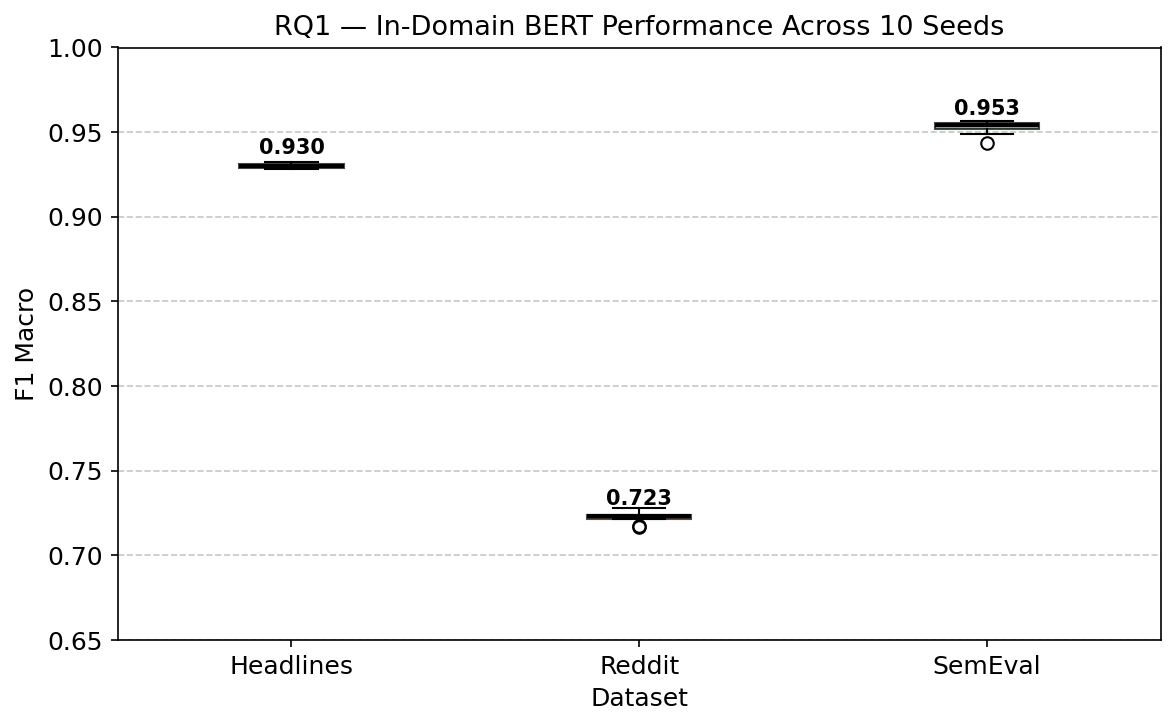

Saved: rq1_boxplot.png


In [12]:
# ===============================
# PLOT 1 — RQ1: BOX PLOT
# Distribution of F1 across 10 seeds per dataset
# ===============================
fig, ax = plt.subplots(figsize=(8, 5))

datasets = ["Headlines", "Reddit", "SemEval"]
data     = [
    rq1_df[rq1_df["dataset"] == d]["f1_macro"].values
    for d in datasets
]

bp = ax.boxplot(data, patch_artist=True, labels=datasets,
                medianprops=dict(color="black", linewidth=2))

colors = ["#4C72B0", "#DD8452", "#55A868"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title("RQ1 — In-Domain BERT Performance Across 10 Seeds")
ax.set_xlabel("Dataset")
ax.set_ylabel("F1 Macro")
ax.set_ylim(0.65, 1.0)
ax.yaxis.grid(True, linestyle="--", alpha=0.7)
ax.set_axisbelow(True)

# Annotate mean values
for i, d in enumerate(data):
    ax.text(i + 1, np.mean(d) + 0.005, f"{np.mean(d):.3f}",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "rq1_boxplot.png"), bbox_inches="tight")
plt.show()
print("Saved: rq1_boxplot.png")

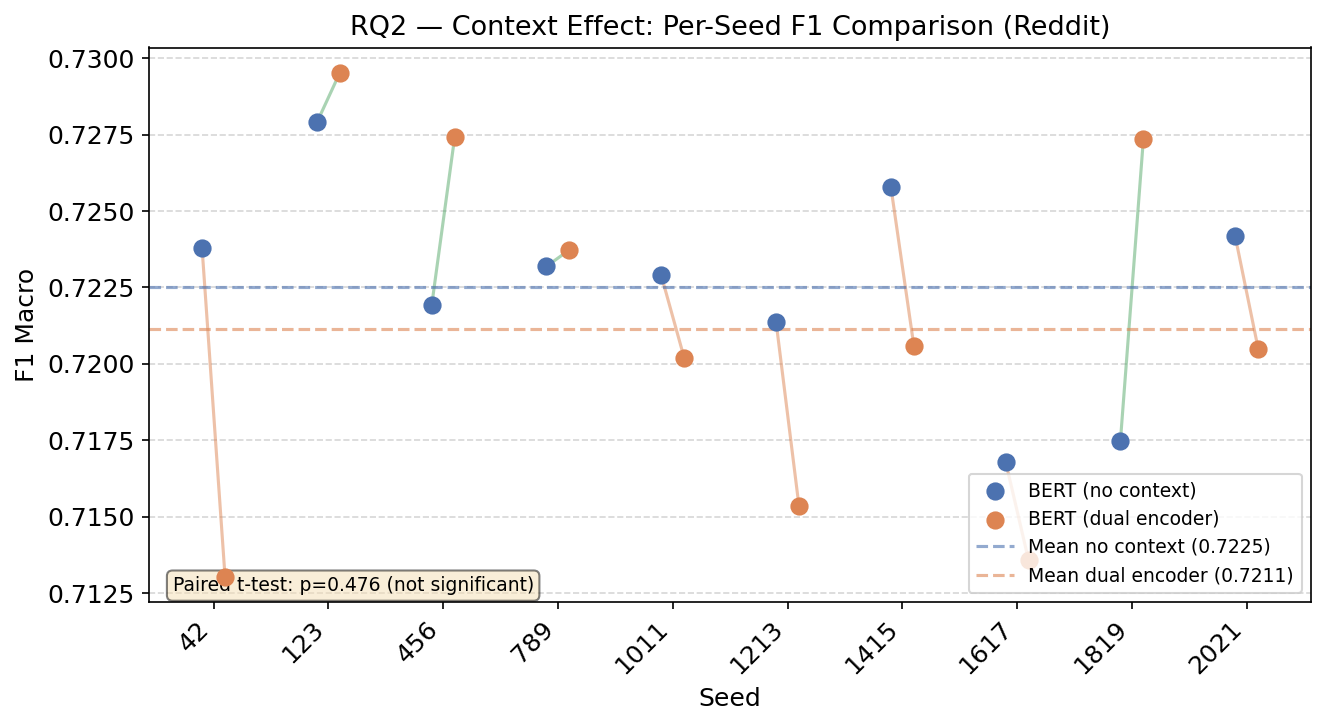

Saved: rq2_paired_lineplot.png


In [13]:
# ===============================
# PLOT 2 — RQ2: PAIRED LINE PLOT
# Per-seed F1 for no context vs dual encoder
# ===============================
fig, ax = plt.subplots(figsize=(9, 5))

rq2_pivot = rq2_df.pivot(index="seed", columns="model", values="f1_macro")
seeds     = rq2_pivot.index.tolist()

no_ctx  = rq2_pivot["BERT (no context)"].values
dual    = rq2_pivot["BERT (dual encoder)"].values

x = np.arange(len(seeds))

# Draw connecting lines per seed
for i in range(len(seeds)):
    color = "#DD8452" if dual[i] < no_ctx[i] else "#55A868"
    ax.plot([x[i] - 0.1, x[i] + 0.1], [no_ctx[i], dual[i]],
            color=color, alpha=0.5, linewidth=1.5)

# Draw dots
ax.scatter(x - 0.1, no_ctx, label="BERT (no context)",
           color="#4C72B0", zorder=5, s=60)
ax.scatter(x + 0.1, dual,   label="BERT (dual encoder)",
           color="#DD8452",  zorder=5, s=60)

# Mean lines
ax.axhline(np.mean(no_ctx), color="#4C72B0", linestyle="--",
           alpha=0.6, label=f"Mean no context ({np.mean(no_ctx):.4f})")
ax.axhline(np.mean(dual),   color="#DD8452", linestyle="--",
           alpha=0.6, label=f"Mean dual encoder ({np.mean(dual):.4f})")

ax.set_xticks(x)
ax.set_xticklabels([str(s) for s in seeds], rotation=45, ha="right")
ax.set_title("RQ2 — Context Effect: Per-Seed F1 Comparison (Reddit)")
ax.set_xlabel("Seed")
ax.set_ylabel("F1 Macro")
ax.legend(loc="lower right", fontsize=9)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

# Annotate p-value
ax.text(0.02, 0.02, "Paired t-test: p=0.476 (not significant)",
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "rq2_paired_lineplot.png"), bbox_inches="tight")
plt.show()
print("Saved: rq2_paired_lineplot.png")

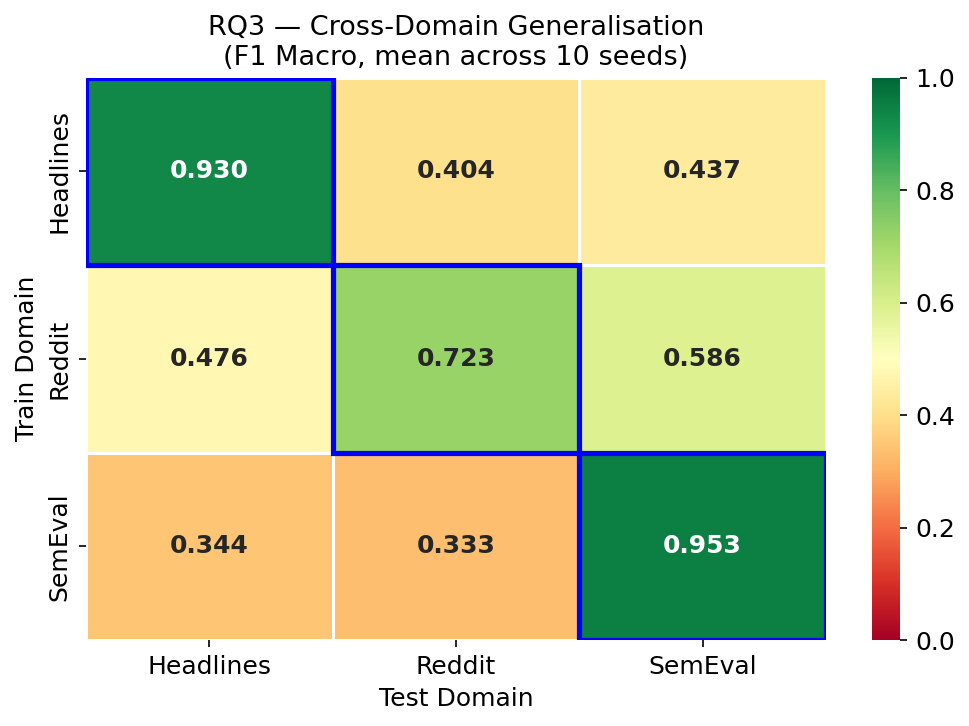

Saved: rq3_heatmap.png


In [14]:
# ===============================
# PLOT 3 — RQ3: HEATMAP
# Train domain vs test domain F1 macro
# Includes in-domain diagonal from RQ1
# ===============================
domains = ["Headlines", "Reddit", "SemEval"]

# Build 3x3 matrix
matrix = np.zeros((3, 3))
for i, train in enumerate(domains):
    for j, test in enumerate(domains):
        if train == test:
            # In-domain from RQ1
            matrix[i, j] = rq1_df[
                rq1_df["dataset"] == train
            ]["f1_macro"].mean()
        else:
            # Cross-domain from RQ3
            mask = (
                (rq3_df["train_domain"] == train) &
                (rq3_df["test_domain"]  == test)
            )
            matrix[i, j] = rq3_df[mask]["f1_macro"].mean()

fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(
    matrix,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",
    vmin=0.0,
    vmax=1.0,
    xticklabels=domains,
    yticklabels=domains,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 12, "weight": "bold"}
)

ax.set_title("RQ3 — Cross-Domain Generalisation\n(F1 Macro, mean across 10 seeds)")
ax.set_xlabel("Test Domain")
ax.set_ylabel("Train Domain")

# Highlight diagonal
for i in range(3):
    ax.add_patch(plt.Rectangle(
        (i, i), 1, 1,
        fill=False, edgecolor="blue", lw=2.5
    ))

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "rq3_heatmap.png"), bbox_inches="tight")
plt.show()
print("Saved: rq3_heatmap.png")

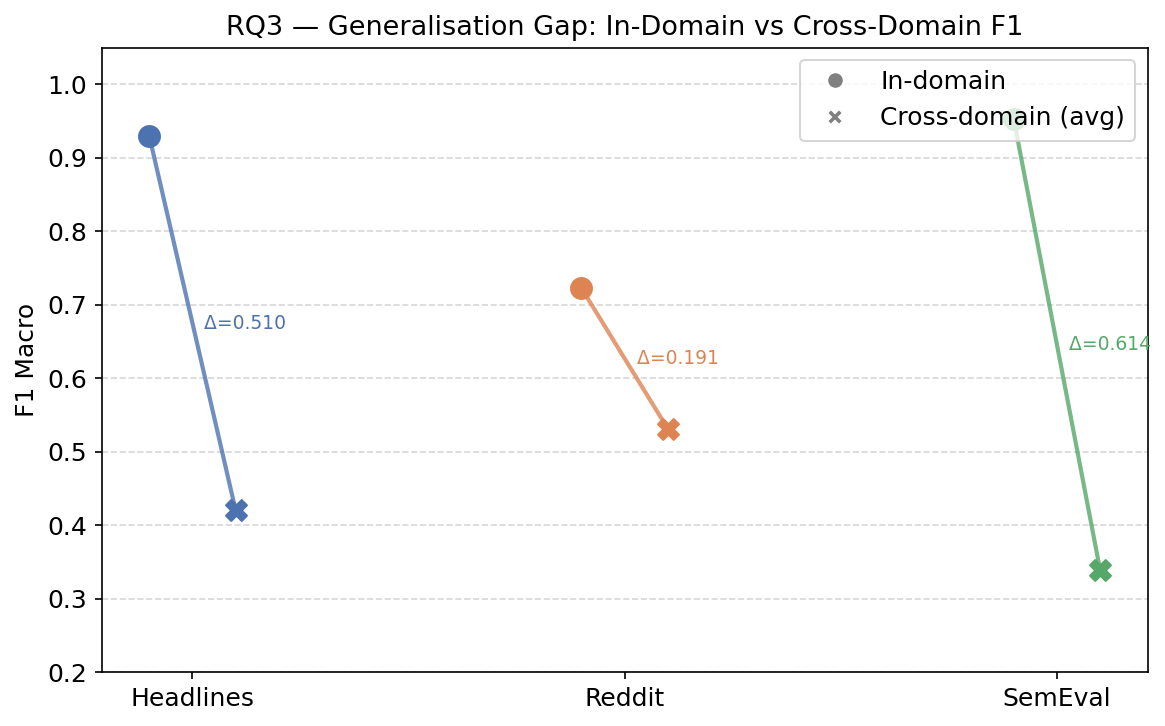

Saved: rq3_drop_chart.png


In [15]:
# ===============================
# PLOT 4 — RQ3: DROP CHART
# In-domain vs cross-domain gap per dataset
# ===============================
fig, ax = plt.subplots(figsize=(8, 5))

colors = {"Headlines": "#4C72B0", "Reddit": "#DD8452", "SemEval": "#55A868"}

for i, domain in enumerate(domains):
    indomain = rq1_df[rq1_df["dataset"] == domain]["f1_macro"].mean()
    crossdomain = rq3_df[
        rq3_df["train_domain"] == domain
    ]["f1_macro"].mean()

    ax.plot([i - 0.1, i + 0.1], [indomain, crossdomain],
            color=colors[domain], linewidth=2, alpha=0.8)
    ax.scatter(i - 0.1, indomain,    color=colors[domain],
               s=100, zorder=5, marker="o")
    ax.scatter(i + 0.1, crossdomain, color=colors[domain],
               s=100, zorder=5, marker="X")

    # Annotate drop
    drop = indomain - crossdomain
    ax.text(i, (indomain + crossdomain) / 2,
            f"  Δ={drop:.3f}", fontsize=9,
            color=colors[domain], va="center")

# Legend
circle = plt.Line2D([0], [0], marker="o", color="w",
                    markerfacecolor="grey", markersize=8, label="In-domain")
cross  = plt.Line2D([0], [0], marker="X", color="w",
                    markerfacecolor="grey", markersize=8, label="Cross-domain (avg)")
ax.legend(handles=[circle, cross], loc="upper right")

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(domains)
ax.set_title("RQ3 — Generalisation Gap: In-Domain vs Cross-Domain F1")
ax.set_ylabel("F1 Macro")
ax.set_ylim(0.2, 1.05)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "rq3_drop_chart.png"), bbox_inches="tight")
plt.show()
print("Saved: rq3_drop_chart.png")

Generating confusion matrix for Headlines...
Generating confusion matrix for Reddit...
Generating confusion matrix for SemEval...


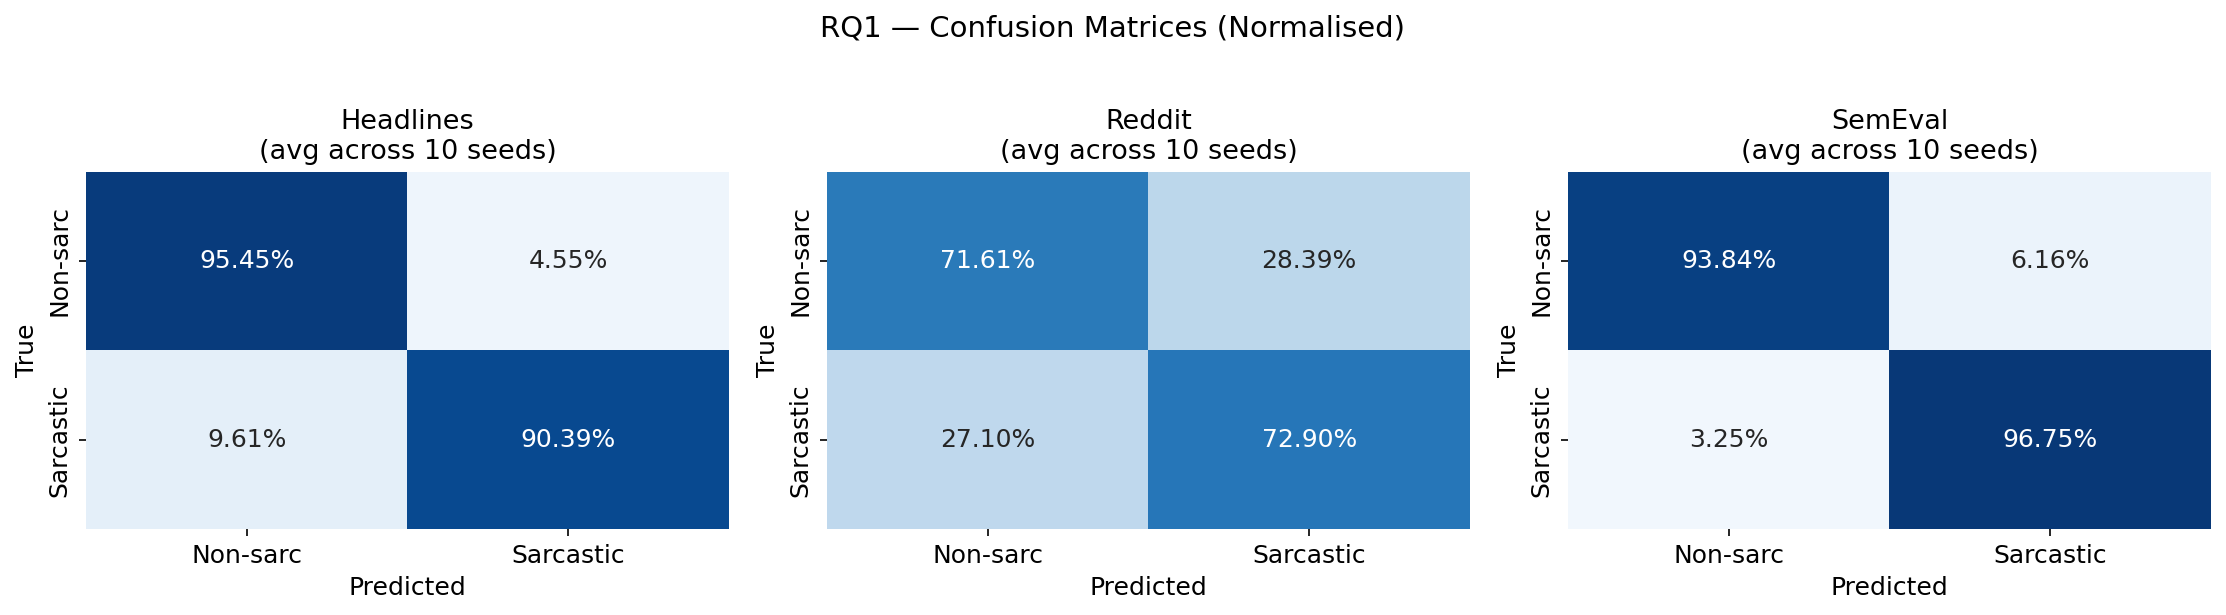

Saved: rq1_confusion_matrices.png


In [20]:
# ===============================
# PLOT 5 — CONFUSION MATRICES
# Averaged across 10 seeds per dataset (RQ1)
# ===============================
sys.path.append(os.path.join(os.getcwd(), ".."))
from src.deep_models import tokenize_data, make_dataloader, predict_bert

def get_averaged_confusion_matrix(dataset_name, test_df, text_col="text"):
    """Load all 10 seed models, get predictions, average confusion matrices."""
    cm_sum = np.zeros((2, 2), dtype=float)

    for seed in SEEDS:
        model_path = os.path.join(
            MODELS_DIR, f"bert_{dataset_name.lower()}_seed{seed}"
        )
        if not os.path.exists(model_path):
            print(f"WARNING: {model_path} not found — skipping")
            continue

        model     = BertForSequenceClassification.from_pretrained(model_path)
        tokenizer = BertTokenizer.from_pretrained(model_path)

        # For Reddit — use same subsample as training
        if dataset_name == "Reddit":
            test_data = test_df.sample(5000, random_state=seed)
        else:
            test_data = test_df

        test_enc    = tokenize_data(test_data[text_col], tokenizer)
        test_loader = make_dataloader(
            test_enc, test_data["label"], shuffle=False
        )

        y_pred = predict_bert(model, test_loader)
        y_true = test_data["label"].values

        cm_sum += confusion_matrix(y_true, y_pred)

    return cm_sum / len(SEEDS)  # average across seeds


# Load test sets
hl_test   = pd.read_csv(os.path.join(PROC_DIR, "headlines_test.csv"))
rd_test   = pd.read_csv(os.path.join(PROC_DIR, "reddit_test.csv"))
se_test   = pd.read_csv(os.path.join(PROC_DIR, "semeval_test.csv"))

test_sets = {
    "Headlines": hl_test,
    "Reddit":    rd_test,
    "SemEval":   se_test,
}

# Generate and plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (dataset_name, test_df) in zip(axes, test_sets.items()):
    print(f"Generating confusion matrix for {dataset_name}...")
    cm = get_averaged_confusion_matrix(dataset_name, test_df)

    # Normalise to percentages
    cm_norm = cm / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2%",
        cmap="Blues",
        vmin=0, vmax=1,
        xticklabels=["Non-sarc", "Sarcastic"],
        yticklabels=["Non-sarc", "Sarcastic"],
        ax=ax,
        cbar=False,
        annot_kws={"size": 12}
    )
    ax.set_title(f"{dataset_name}\n(avg across 10 seeds)")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.suptitle("RQ1 — Confusion Matrices (Normalised)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "rq1_confusion_matrices.png"),
            bbox_inches="tight")
plt.show()
print("Saved: rq1_confusion_matrices.png")

Generating confusion matrix: SemEval → Headlines...
Generating confusion matrix: SemEval → Reddit...
Generating confusion matrix: Reddit → SemEval...


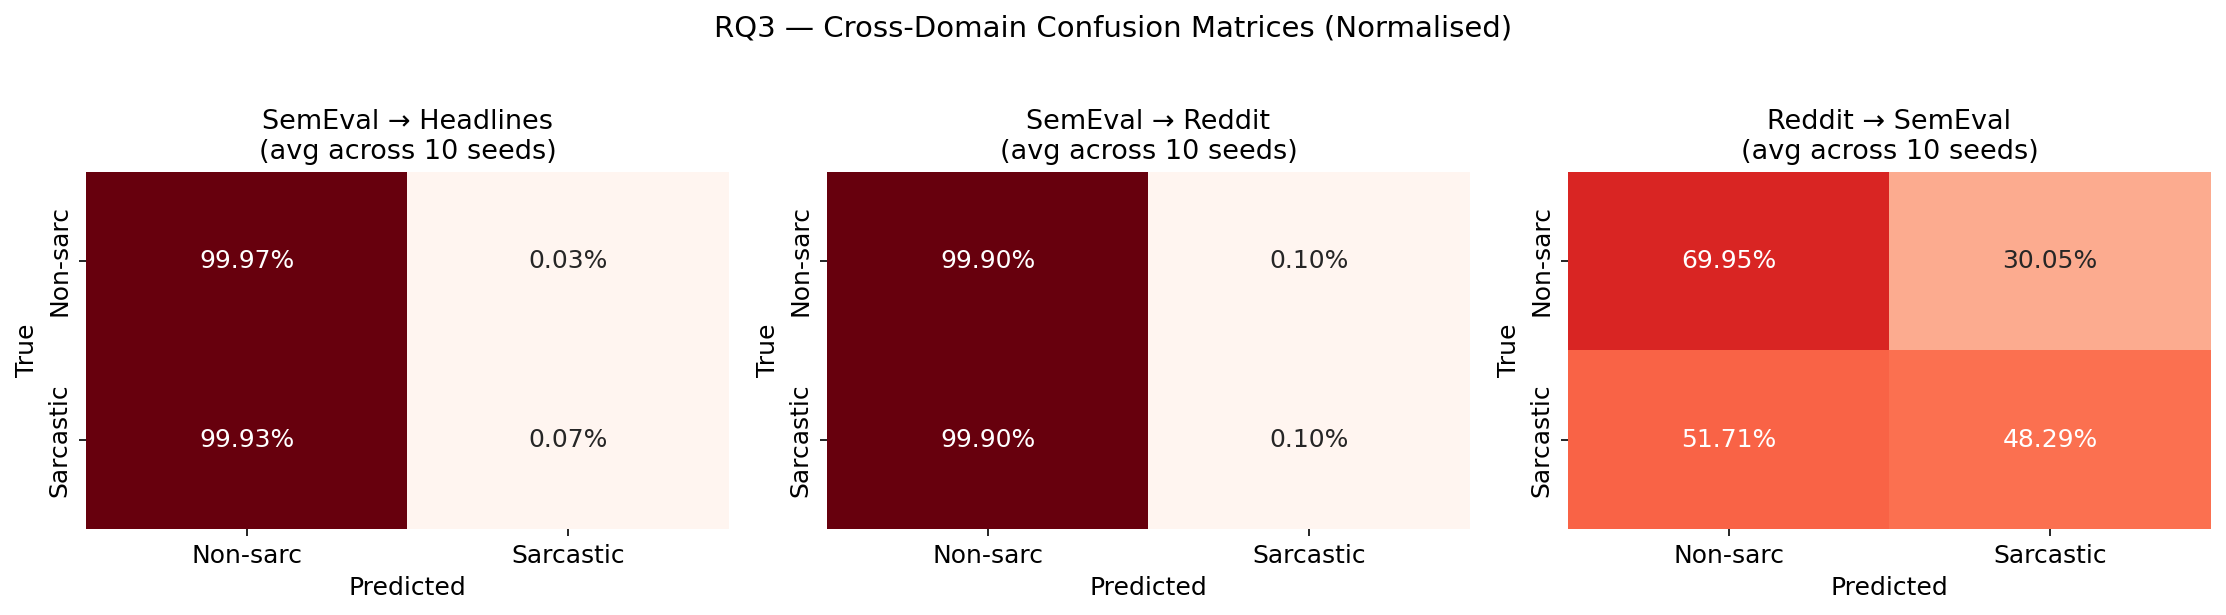

Saved: rq3_confusion_matrices.png


In [21]:
# ===============================
# PLOT 6 — RQ3: CONFUSION MATRICES
# Most interesting cross-domain pairs
# SemEval → Reddit and SemEval → Headlines
# ===============================
def get_crossdomain_confusion_matrix(train_domain, test_domain,
                                     test_df, text_col="text"):
    cm_sum = np.zeros((2, 2), dtype=float)

    for seed in SEEDS:
        model_path = os.path.join(
            MODELS_DIR, f"bert_{train_domain.lower()}_seed{seed}"
        )
        if not os.path.exists(model_path):
            continue

        model     = BertForSequenceClassification.from_pretrained(model_path)
        tokenizer = BertTokenizer.from_pretrained(model_path)

        if test_domain == "Reddit":
            test_data = test_df.sample(5000, random_state=seed)
        else:
            test_data = test_df

        test_enc    = tokenize_data(test_data[text_col], tokenizer)
        test_loader = make_dataloader(
            test_enc, test_data["label"], shuffle=False
        )

        y_pred = predict_bert(model, test_loader)
        y_true = test_data["label"].values
        cm_sum += confusion_matrix(y_true, y_pred)

    return cm_sum / len(SEEDS)


# Most interesting pairs based on results
interesting_pairs = [
    ("SemEval",   "Headlines", hl_test),
    ("SemEval",   "Reddit",    rd_test),
    ("Reddit",    "SemEval",   se_test),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (train_d, test_d, test_df) in zip(axes, interesting_pairs):
    print(f"Generating confusion matrix: {train_d} → {test_d}...")
    cm      = get_crossdomain_confusion_matrix(train_d, test_d, test_df)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2%",
        cmap="Reds",
        vmin=0, vmax=1,
        xticklabels=["Non-sarc", "Sarcastic"],
        yticklabels=["Non-sarc", "Sarcastic"],
        ax=ax,
        cbar=False,
        annot_kws={"size": 12}
    )
    ax.set_title(f"{train_d} → {test_d}\n(avg across 10 seeds)")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.suptitle("RQ3 — Cross-Domain Confusion Matrices (Normalised)",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "rq3_confusion_matrices.png"),
            bbox_inches="tight")
plt.show()
print("Saved: rq3_confusion_matrices.png")